In [28]:
import pandas as pd
import numpy as np
import tensorflow as tf

In [29]:
import kagglehub
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os
from  glob import glob
from sklearn.model_selection import train_test_split
import keras
from keras.layers import Flatten, Dense,GRU, LSTM, RNN
from keras.models import Sequential
from sklearn.preprocessing import LabelEncoder ,  OneHotEncoder

In [30]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andradaolteanu/gtzan-dataset-music-genre-classification")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\user\.cache\kagglehub\datasets\andradaolteanu\gtzan-dataset-music-genre-classification\versions\1


In [31]:
blues = r'C:\Users\user\.cache\kagglehub\datasets\andradaolteanu\gtzan-dataset-music-genre-classification\versions\blues'
classic = r'C:\Users\user\.cache\kagglehub\datasets\andradaolteanu\gtzan-dataset-music-genre-classification\versions\classic'
country = r'C:\Users\user\.cache\kagglehub\datasets\andradaolteanu\gtzan-dataset-music-genre-classification\versions\country'
disco = r'C:\Users\user\.cache\kagglehub\datasets\andradaolteanu\gtzan-dataset-music-genre-classification\versions\disco'
hiphop = r'C:\Users\user\.cache\kagglehub\datasets\andradaolteanu\gtzan-dataset-music-genre-classification\versions\hiphop'
jazz = r'C:\Users\user\.cache\kagglehub\datasets\andradaolteanu\gtzan-dataset-music-genre-classification\versions\jazz'
metall = r'C:\Users\user\.cache\kagglehub\datasets\andradaolteanu\gtzan-dataset-music-genre-classification\versions\metall'
pop = r'C:\Users\user\.cache\kagglehub\datasets\andradaolteanu\gtzan-dataset-music-genre-classification\versions\pop'
reggae = r'C:\Users\user\.cache\kagglehub\datasets\andradaolteanu\gtzan-dataset-music-genre-classification\versions\reggae'
rock = r'C:\Users\user\.cache\kagglehub\datasets\andradaolteanu\gtzan-dataset-music-genre-classification\versions\rock'

In [32]:
dataset_30sec = pd.read_csv(r'C:\Users\user\.cache\kagglehub\datasets\andradaolteanu\gtzan-dataset-music-genre-classification\versions\1\Data\features_30_sec.csv')

In [33]:
dataset_30sec

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,rock.00095.wav,661794,0.352063,0.080487,0.079486,0.000345,2008.149458,282174.689224,2106.541053,88609.749506,...,45.050526,-13.289984,41.754955,2.484145,36.778877,-6.713265,54.866825,-1.193787,49.950665,rock
996,rock.00096.wav,661794,0.398687,0.075086,0.076458,0.000588,2006.843354,182114.709510,2068.942009,82426.016726,...,33.851742,-10.848309,39.395096,1.881229,32.010040,-7.461491,39.196327,-2.795338,31.773624,rock
997,rock.00097.wav,661794,0.432142,0.075268,0.081651,0.000322,2077.526598,231657.968040,1927.293153,74717.124394,...,33.597008,-12.845291,36.367264,3.440978,36.001110,-12.588070,42.502201,-2.106337,29.865515,rock
998,rock.00098.wav,661794,0.362485,0.091506,0.083860,0.001211,1398.699344,240318.731073,1818.450280,109090.207161,...,46.324894,-4.416050,43.583942,1.556207,34.331261,-5.041897,47.227180,-3.590644,41.299088,rock


In [34]:
test = dataset_30sec.copy()

In [35]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
test['label'] = encoder.fit_transform(test['label'])

In [36]:
X = test.drop(['label', 'filename'], axis=1)  # Все столбцы кроме 'label' - это признаки
y = test['label']

In [37]:
classies = y.unique()

In [38]:
classies = encoder.fit_transform(classies)

In [39]:
print(y[:5]) 

0    0
1    0
2    0
3    0
4    0
Name: label, dtype: int64


In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size = 0.25, shuffle = True)

In [41]:
X_train.shape

(750, 58)

In [42]:
print(f"Размер X_train: {X_train.shape}")
print(f"Размер X_test: {X_test.shape}")
print(f"Количество уникальных классов в y_train: {len(np.unique(y_train))}")
print(f"Уникальные классы: {np.unique(y_train)}")
print(f"Распределение классов в y_train:\n{pd.Series(y_train).value_counts()}")
print(f"Распределение классов в y_test:\n{pd.Series(y_test).value_counts()}")
print(f"Тип данных X_train: {type(X_train)}")
print(f"Наличие NaN в X_train: {X_train.isna().any().any()}")
print(f"Диапазон значений в X_train: min={X_train.min().min():.4f}, max={X_train.max().max():.4f}")

Размер X_train: (750, 58)
Размер X_test: (250, 58)
Количество уникальных классов в y_train: 10
Уникальные классы: [0 1 2 3 4 5 6 7 8 9]
Распределение классов в y_train:
label
7    84
1    83
4    82
8    73
3    73
9    72
6    72
0    71
5    71
2    69
Name: count, dtype: int64

Распределение классов в y_test:
label
2    31
5    29
0    29
6    28
9    28
8    27
3    27
4    18
1    17
7    16
Name: count, dtype: int64

Тип данных X_train: <class 'pandas.core.frame.DataFrame'>
Наличие NaN в X_train: False
Диапазон значений в X_train: min=-552.1201, max=8660900.4844


In [43]:
from tensorflow import keras
from keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
target_names = [str(cls) for cls in np.unique(y_train)]

X_train_np = X_train.values
X_test_np = X_test.values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_np)
X_test_scaled = scaler.transform(X_test_np)


y_train_cat = to_categorical(y_train, num_classes=len(np.unique(y_train)))
y_test_cat = to_categorical(y_test, num_classes=len(np.unique(y_train)))

model_mlp = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(len(np.unique(y_train)), activation='softmax')
])

model_mlp.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_mlp = model_mlp.fit(
    X_train_scaled, y_train_cat, 
    epochs=100, batch_size=32, 
    validation_data=(X_test_scaled, y_test_cat), 
    verbose=1,
    callbacks=[keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)]
)

pred_mlp = model_mlp.predict(X_test_scaled)
pred_classes_mlp = np.argmax(pred_mlp, axis=1)
accuracy_mlp = accuracy_score(y_test, pred_classes_mlp)

print(f"Accuracy: {accuracy_mlp:.4f} ({accuracy_mlp*100:.2f}%)")


Epoch 1/100


C:\Users\user\Downloads\UDL Downloads\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.1467 - loss: 2.4433 - val_accuracy: 0.3200 - val_loss: 2.1022
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3080 - loss: 1.9443 - val_accuracy: 0.3840 - val_loss: 1.9385
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4227 - loss: 1.7162 - val_accuracy: 0.4520 - val_loss: 1.7791
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4867 - loss: 1.5577 - val_accuracy: 0.4880 - val_loss: 1.6386
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5427 - loss: 1.3891 - val_accuracy: 0.5240 - val_loss: 1.4931
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5587 - loss: 1.2797 - val_accuracy: 0.5440 - val_loss: 1.3724
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5880 - loss: 1.2192 - val_accuracy: 0.5760 - val_loss: 1.2771
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6027 - loss: 1.1638 - val_accuracy: 0.5680 - val_loss: 1.

In [44]:
num_classes = len(np.unique(y_train))
print(f"Количество классов: {num_classes}")

Количество классов: 10


In [45]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [46]:
X_train_rnn = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_rnn = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

In [47]:
rnn_model = keras.Sequential([
    keras.layers.Input(shape=(1, X_train_scaled.shape[1])),
    keras.layers.SimpleRNN(64, return_sequences=False),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(num_classes, activation='softmax')
])

rnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
rnn_model.summary()

history_rnn = rnn_model.fit(
    X_train_rnn, y_train_cat,
    epochs=100, 
    batch_size=32,
    validation_data=(X_test_rnn, y_test_cat),
    verbose=1,
    callbacks=[early_stopping, reduce_lr]
)

# Предсказания RNN
pred_rnn = rnn_model.predict(X_test_rnn)
pred_classes_rnn = np.argmax(pred_rnn, axis=1)
accuracy_rnn = accuracy_score(y_test, pred_classes_rnn)
print(f"Точность RNN: {accuracy_rnn:.4f} ({accuracy_rnn*100:.2f}%)")

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn_5 (SimpleRNN)             │ (None, 64)                  │           7,872 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_16 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_27 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_17 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_28 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_29 (Dense)                     │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,698 (57.41 KB)

 Trainable params: 14,570 (56.91 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.1133 - loss: 2.5983 - val_accuracy: 0.2240 - val_loss: 2.1931 - learning_rate: 0.0010
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2667 - loss: 2.0708 - val_accuracy: 0.3600 - val_loss: 2.0139 - learning_rate: 0.0010
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3480 - loss: 1.8331 - val_accuracy: 0.3760 - val_loss: 1.8718 - learning_rate: 0.0010
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4133 - loss: 1.6542 - val_accuracy: 0.4080 - val_loss: 1.7323 - learning_rate: 0.0010
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4373 - loss: 1.5256 - val_accuracy: 0.4640 - val_loss: 1.6133 - learning_rate: 0.0010
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4893 - loss: 1.4279 - val_accuracy: 0.5000 - val_loss: 1.5143 - learning_rate: 0.0010
Epoch 7/100
18/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4991 - loss: 1.3585 
Epoch 7

In [58]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV


# Оптимизированный Random Forest
rf_best = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_best.fit(X_train_scaled, y_train)
rf_pred = rf_best.predict(X_test_scaled)
accuracy_rf = accuracy_score(y_test, rf_pred)
print(f"Точность Random Forest: {accuracy_rf:.4f} ({accuracy_rf*100:.2f}%)")

Точность Random Forest: 0.7440 (74.40%)


In [49]:
X_train_cnn = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_test_cnn = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))
simple_cnn = keras.Sequential([
   
    keras.layers.Input(shape=(X_train_scaled.shape[1], 1)),
    
    
    keras.layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling1D(pool_size=2),
    keras.layers.Dropout(0.25),
    
    
    keras.layers.Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling1D(pool_size=2),
    keras.layers.Dropout(0.25),
    
    
    keras.layers.Conv1D(filters=256, kernel_size=3, activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.GlobalAveragePooling1D(),
    keras.layers.Dropout(0.3),
    
    
    keras.layers.Dense(128, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.2),
    
    
    keras.layers.Dense(num_classes, activation='softmax')
])


simple_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

simple_cnn.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)                    │ (None, 58, 64)              │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ (None, 58, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 29, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_23 (Dropout)                 │ (None, 29, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_4 (Conv1D)                    │ (None, 29, 128)             │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_14               │ (None, 29, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_3 (MaxPooling1D)       │ (None, 14, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_24 (Dropout)                 │ (None, 14, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_5 (Conv1D)                    │ (None, 14, 256)             │          98,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_15               │ (None, 14, 256)             │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d_1           │ (None, 256)                 │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_25 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_33 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_16               │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_26 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_34 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_27 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_35 (Dense)                     │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 167,626 (654.79 KB)

 Trainable params: 166,474 (650.29 KB)

 Non-trainable params: 1,152 (4.50 KB)

In [50]:
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=20,
    restore_best_weights=True,
    verbose=1,
    mode='max'
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=8,
    min_lr=0.00001,
    verbose=1
)


history_simple_cnn = simple_cnn.fit(
    X_train_cnn, y_train_cat,
    epochs=150,
    batch_size=32,
    validation_data=(X_test_cnn, y_test_cat),
    verbose=1,
    callbacks=[early_stopping, reduce_lr]
)

pred_simple_cnn = simple_cnn.predict(X_test_cnn)
pred_classes_simple_cnn = np.argmax(pred_simple_cnn, axis=1)
accuracy_simple_cnn = accuracy_score(y_test, pred_classes_simple_cnn)
print(f"Accuracy cnn: {accuracy_simple_cnn:.4f} ({accuracy_simple_cnn*100:.2f}%)")

Epoch 1/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.2187 - loss: 2.4616 - val_accuracy: 0.1440 - val_loss: 2.2631 - learning_rate: 0.0010
Epoch 2/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2933 - loss: 2.0481 - val_accuracy: 0.1320 - val_loss: 2.2624 - learning_rate: 0.0010
Epoch 3/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3613 - loss: 1.8195 - val_accuracy: 0.1320 - val_loss: 2.2982 - learning_rate: 0.0010
Epoch 4/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3667 - loss: 1.7850 - val_accuracy: 0.1280 - val_loss: 2.3792 - learning_rate: 0.0010
Epoch 5/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3840 - loss: 1.7185 - val_accuracy: 0.1280 - val_loss: 2.5895 - learning_rate: 0.0010
Epoch 6/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4000 - loss: 1.6785 - val_accuracy: 0.1280 - val_loss: 2.9340 - learning_rate: 0.0010
Epoch 7/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4400 - loss: 1.5274 - 

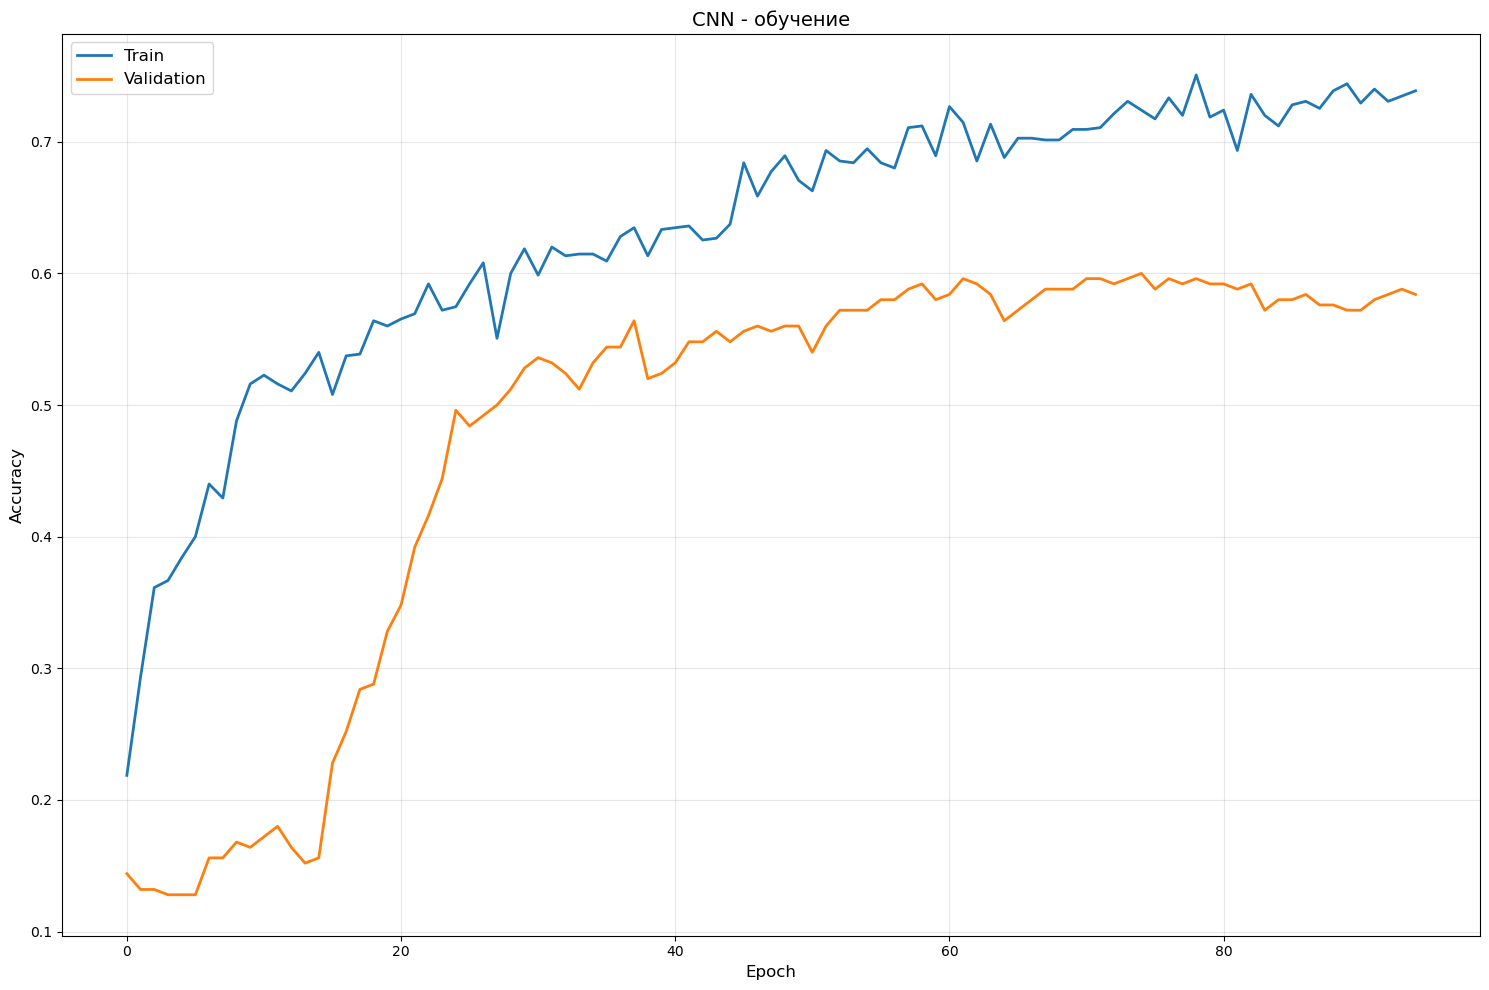

In [54]:
fig, ax = plt.subplots(1, figsize=(15, 10))  # Создаем 1 график

ax.plot(history_simple_cnn.history['accuracy'], label='Train', linewidth=2)
ax.plot(history_simple_cnn.history['val_accuracy'], label='Validation', linewidth=2)
ax.set_title('CNN - обучение', fontsize=14)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

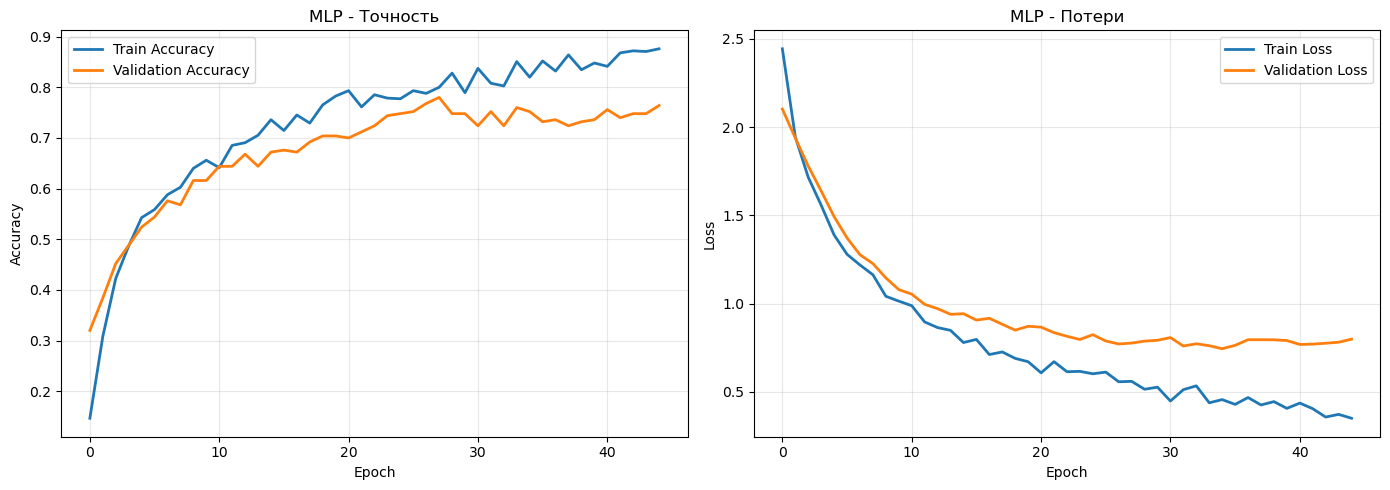

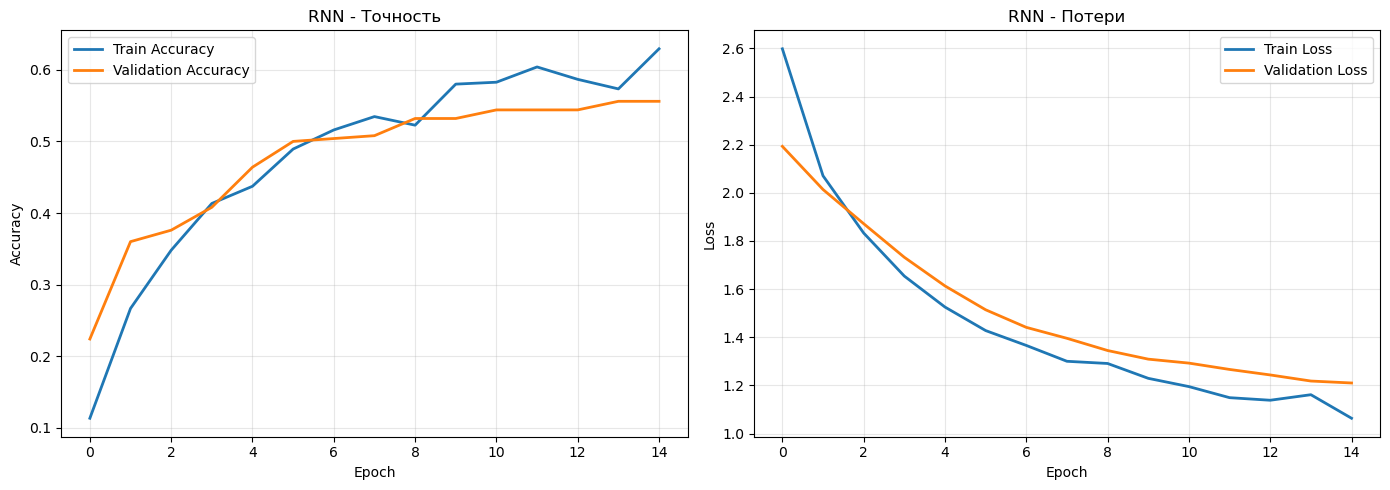

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График точности MLP
axes[0].plot(history_mlp.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history_mlp.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title('MLP - Точность', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


axes[1].plot(history_mlp.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history_mlp.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title('MLP - Потери', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_rnn.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history_rnn.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title('RNN - Точность', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


axes[1].plot(history_rnn.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history_rnn.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title('RNN - Потери', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [57]:
import librosa
import librosa.display
def extract_advanced_features(file_path):
    """Извлечение расширенных аудио признаков с помощью librosa"""
    
    # Загрузка аудио
    y, sr = librosa.load(file_path, duration=30)
    
    # Базовые признаки
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    mel = librosa.feature.melspectrogram(y=y, sr=sr)
    
    # Статистики для MFCC
    mfcc_mean = np.mean(mfccs, axis=1)
    mfcc_std = np.std(mfccs, axis=1)
    mfcc_var = np.var(mfccs, axis=1)
    
    # Спектральные признаки
    spectral_centroids = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)[0]
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]
    zero_crossing_rate = librosa.feature.zero_crossing_rate(y)[0]
    
    # Тембровые признаки
    rms = librosa.feature.rms(y=y)[0]
    
    # Темп и биты
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    
    # Хроматические особенности
    chroma_mean = np.mean(chroma, axis=1)
    chroma_std = np.std(chroma, axis=1)
    
    # Мел-спектрограмма признаки
    mel_mean = np.mean(mel, axis=1)
    mel_std = np.std(mel, axis=1)
    
    # Объединяем все признаки
    features = np.concatenate([
        mfcc_mean, mfcc_std, mfcc_var,
        [np.mean(spectral_centroids), np.std(spectral_centroids)],
        [np.mean(spectral_rolloff), np.std(spectral_rolloff)],
        [np.mean(spectral_bandwidth), np.std(spectral_bandwidth)],
        [np.mean(zero_crossing_rate), np.std(zero_crossing_rate)],
        [np.mean(rms), np.std(rms)],
        [tempo],
        chroma_mean, chroma_std,
        mel_mean[:10], mel_std[:10]  # Берем первые 10 для mel
    ])
    
    return features

def extract_features_batch(file_paths, labels):
    """Пакетное извлечение признаков"""
    features_list = []
    for i, file_path in enumerate(file_paths):
        try:
            features = extract_advanced_features(file_path)
            features_list.append(features)
            if (i + 1) % 100 == 0:
                print(f"Обработано {i + 1} файлов...")
        except Exception as e:
            print(f"Ошибка при обработке {file_path}: {e}")
            continue
    
    return np.array(features_list), np.array(labels)

In [60]:
def plot_spectrograms(file_path, genre):
    """Визуализация различных спектрограмм аудио"""
    
    y, sr = librosa.load(file_path, duration=30)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(f'Спектрограммы для жанра: {genre}', fontsize=16)
    
    # 1. Волновая форма
    axes[0, 0].plot(np.linspace(0, len(y)/sr, len(y)), y)
    axes[0, 0].set_title('Волновая форма')
    axes[0, 0].set_xlabel('Время (с)')
    axes[0, 0].set_ylabel('Амплитуда')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Спектрограмма (STFT)
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    img = librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log', ax=axes[0, 1])
    axes[0, 1].set_title('Спектрограмма (STFT)')
    plt.colorbar(img, ax=axes[0, 1], format='%+2.0f dB')
    
    # 3. Мел-спектрограмма
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr)
    mel_db = librosa.amplitude_to_db(mel_spec, ref=np.max)
    img = librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[0, 2])
    axes[0, 2].set_title('Мел-спектрограмма')
    plt.colorbar(img, ax=axes[0, 2], format='%+2.0f dB')
    
    # 4. MFCC
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    img = librosa.display.specshow(mfccs, sr=sr, x_axis='time', ax=axes[1, 0])
    axes[1, 0].set_title('MFCC (Mel-frequency cepstral coefficients)')
    plt.colorbar(img, ax=axes[1, 0])
    
    # 5. Хромограмма
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    img = librosa.display.specshow(chroma, sr=sr, x_axis='time', y_axis='chroma', ax=axes[1, 1])
    axes[1, 1].set_title('Хромограмма (12 тонов)')
    plt.colorbar(img, ax=axes[1, 1])
    
    # 6. Spectral rolloff и centroid
    spectral_centroids = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)[0]
    times = librosa.times_like(spectral_centroids, sr=sr)
    
    axes[1, 2].plot(times, spectral_centroids, label='Spectral Centroid', alpha=0.7)
    axes[1, 2].plot(times, spectral_rolloff, label='Spectral Rolloff', alpha=0.7)
    axes[1, 2].set_title('Спектральные характеристики')
    axes[1, 2].set_xlabel('Время (с)')
    axes[1, 2].set_ylabel('Частота (Hz)')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()